In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

from preprocess import load_and_sample, preprocess
from train import split_data, build_tfidf, train_baselines, plot_wordclouds, save_pipeline

In [2]:
# -- 1. LOAD & SAMPLE
df = load_and_sample('data/raw/Reviews.csv', n=100000)
print(df.head())

Loaded 100,000 reviews.
sentiment
positive    78263
negative    14315
neutral      7422
Name: count, dtype: int64
   Score                                               Text sentiment
0      5  Having tried a couple of other brands of glute...  positive
1      5  My cat loves these treats. If ever I can't fin...  positive
2      3  A little less than I expected.  It tends to ha...   neutral
3      2  First there was Frosted Mini-Wheats, in origin...  negative
4      5  and I want to congratulate the graphic artist ...  positive


In [3]:
# -- 2. PREPROCESS
df = preprocess(df)
print(df[['Text', 'clean_text', 'sentiment']].head())

Preprocessing complete. Shape: (99999, 4)
                                                Text  \
0  Having tried a couple of other brands of glute...   
1  My cat loves these treats. If ever I can't fin...   
2  A little less than I expected.  It tends to ha...   
3  First there was Frosted Mini-Wheats, in origin...   
4  and I want to congratulate the graphic artist ...   

                                          clean_text sentiment  
0  tried couple brands gluten free sandwich cooki...  positive  
1  cat loves treats ever find house pop top bolts...  positive  
2  little less expected tends muddy taste expecte...   neutral  
3  first frosted mini wheats original size froste...  negative  
4  want congratulate graphic artist putting entir...  positive  


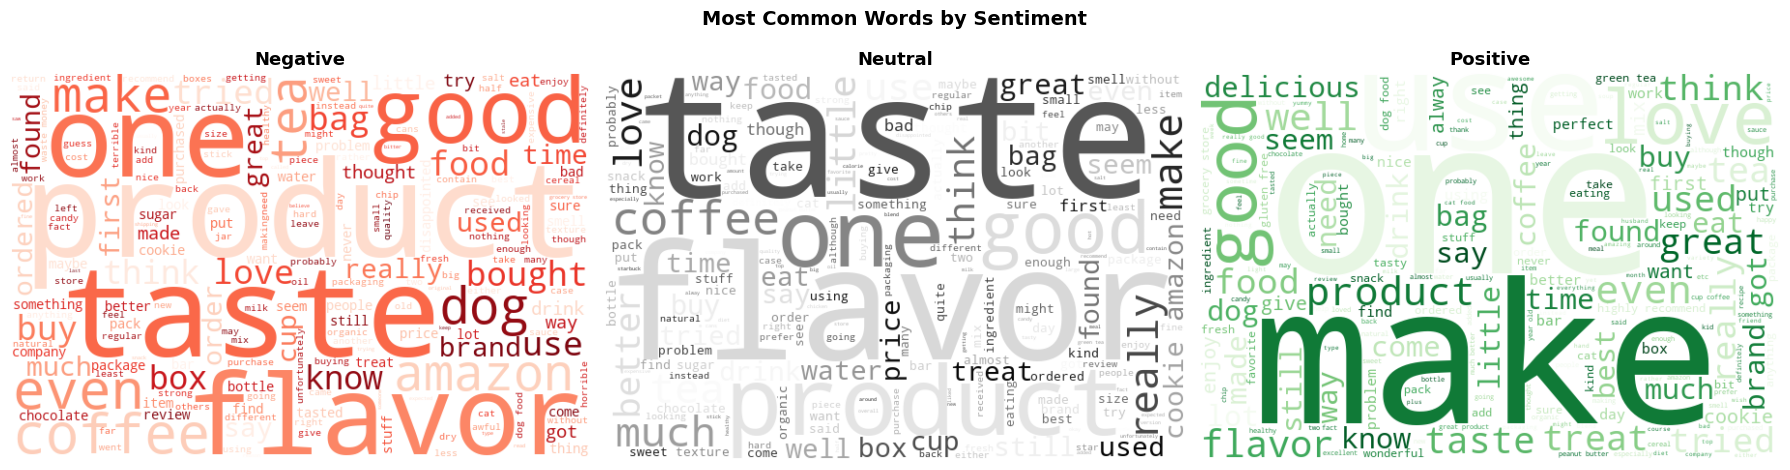

In [4]:
# -- 3. WORDCLOUDS
plot_wordclouds(df)

In [5]:
# -- 4. SPLIT & VECTORIZE
X_train, X_test, y_train, y_test = split_data(df)
X_tr_tfidf, X_te_tfidf, vectorizer = build_tfidf(X_train, X_test)


-- Logistic Regression --
              precision    recall  f1-score   support

    negative       0.64      0.76      0.69      2863
     neutral       0.30      0.55      0.39      1484
    positive       0.96      0.85      0.90     15653

    accuracy                           0.82     20000
   macro avg       0.63      0.72      0.66     20000
weighted avg       0.86      0.82      0.83     20000


-- Naive Bayes --
              precision    recall  f1-score   support

    negative       0.87      0.31      0.46      2863
     neutral       0.33      0.00      0.01      1484
    positive       0.82      1.00      0.90     15653

    accuracy                           0.82     20000
   macro avg       0.68      0.44      0.45     20000
weighted avg       0.79      0.82      0.77     20000



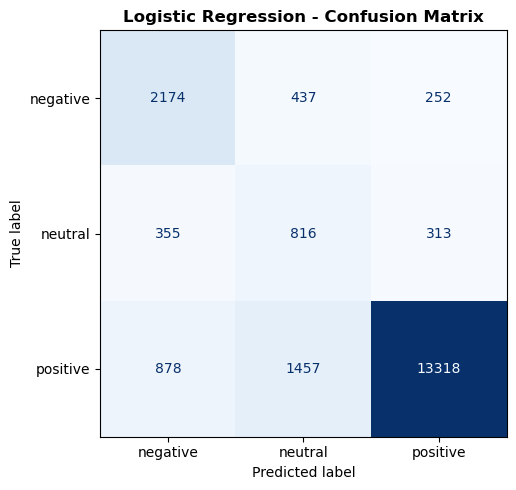

In [6]:
# -- 5. TRAIN BASELINES
trained = train_baselines(X_tr_tfidf, y_train, X_te_tfidf, y_test)


In [7]:
# -- 6. SAVE PIPELINE
save_pipeline(trained['Logistic Regression'], vectorizer)

Model saved to models/sentiment_model.pkl
Vectorizer saved to models/tfidf_vectorizer.pkl


In [8]:
# -- 7. TEST INFERENCE
from predict import load_pipeline, predict_sentiment

model, vec = load_pipeline()

samples = [
    'This is the best product I have ever bought. Absolutely love it!',
    'It was okay, nothing special. Does the job I guess.',
    'Terrible quality. Broke after one use. Complete waste of money.'
]
for s in samples:
    print(predict_sentiment(s, model, vec))


{'text': 'This is the best product I have ever bought. Absolutely love it!', 'sentiment': 'positive', 'confidence': 93.67}
{'text': 'It was okay, nothing special. Does the job I guess.', 'sentiment': 'neutral', 'confidence': 98.68}
{'text': 'Terrible quality. Broke after one use. Complete waste of money.', 'sentiment': 'negative', 'confidence': 99.95}
